In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [4]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        return Value(self.data+other.data, (self, other), '+')
    def __mul__(self, other):
        return Value(self.data*other.data, (self, other), '*')
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        return Value(t, (self, ), 'tanh')

In [5]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for to in v._prev:
                edges.add((to, v))
                build(to)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for v in nodes:
        uid = str(id(v))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (v.label, v.data, v.grad), shape='record')
        if v._op:
            dot.node(name=uid+v._op, label=v._op)
            dot.edge(uid+v._op, uid)
    for v, u in edges:
        dot.edge(str(id(v)), str(id(u)) + u._op)
    return dot

In [6]:
def lol():
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)

lol()

0.0


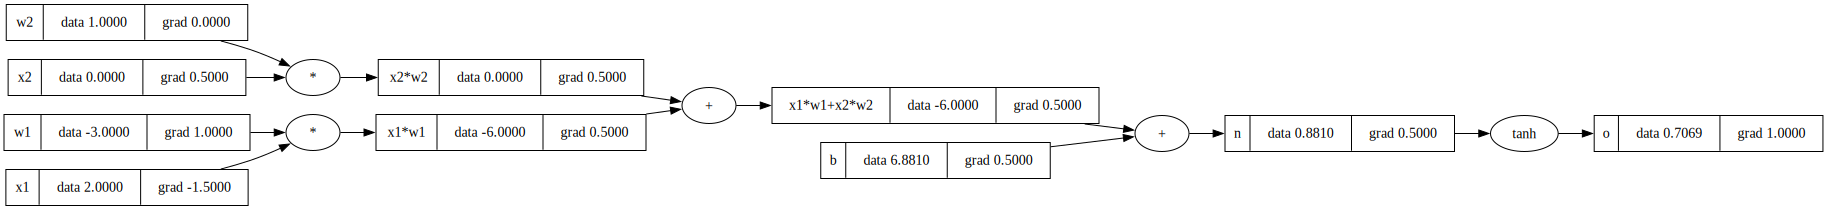

In [30]:
h = 0.0001
# inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias
b = Value(6.881, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label = 'x1*w1+x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.grad = 1.0
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
w1.grad = x1.data*x1w1.grad
x1.grad = w1.data*x1w1.grad
w2.grad = x2.data*x2w2.grad
x2.grad = w2.data*x2w2.grad

draw_dot(o)